# Appendix — supplementary / robustness analyses

This notebook runs the four standalone reporting scripts that back the
supplementary figures and the reviewer-facing robustness checks. They are *not*
part of the main `01`–`07` pipeline; they re-use the persisted joint coordinates
(`assets/reports/joint_umap_*_xy.tsv`) and the shipped tables, so **no UMAP /
BERTopic re-run is needed** — only notebook `03`/`04` must have produced the
coordinates first.

| § | Script | What it answers | Outputs (`assets/reports/`) |
|---|--------|-----------------|------------------------------|
| 1 | `density_eras.py` | **R2** — is the teams-vs-papers spatial division of labour stable across eras (2004–2014 vs 2015–2025)? | `density_ratio_eras.png` |
| 2 | `geography_lq.py` | Geographic specialization of the outsider community via Location Quotient | `geography_location_quotient.tsv`, `geography_lq.png` |
| 3 | `geography_topic_matrix.py` | Do outsider-tilted countries concentrate in the iGEM-led topics? (ties geography → precedence) | `geography_topic_matrix.tsv`, `geography_topic_matrix.png`, `geography_lead_orientation.png` |
| 4 | `precedence_robustness.py` | **R1** — does the precedence result survive changes in year statistic and neighbourhood parameters? | `precedence_robustness.tsv`, `precedence_robustness_sensitivity.tsv`, `precedence_robustness.png` |

> **Order matters:** §3 reads the `geography_location_quotient.tsv` that §2 writes,
> so run the cells top to bottom.

## Setup

Run each script from this notebook's directory (`05-reporting/`) so that `%run`
resolves the scripts and each script's `ASSETS = Path(__file__).parents[1]/"assets"`
points at the repo's `assets/`.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Locate 05-reporting robustly whether the kernel started here or at the repo root.
_candidates = [Path.cwd(), Path.cwd() / "05-reporting"]
REPORTING = next((p for p in _candidates if (p / "density_eras.py").exists()), None)
assert REPORTING is not None, f"Could not locate 05-reporting from {Path.cwd()}"
os.chdir(REPORTING)
REPORTS = REPORTING.parent / "assets" / "reports"
print("Working directory:", Path.cwd())
print("Reports directory:", REPORTS)

Working directory: /Users/cristian/Desktop/GitHub/igem-synbio/05-reporting
Reports directory: /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports


## 1 · Density ratio across eras (R2)

Recomputes the self-normalised `log2(teams density / papers density)` map
separately for 2004–2014 and 2015–2025 on one shared grid, then reports the
grid-cell correlation and per-topic zone agreement between the two eras.

2004–2014: 5,511 papers, 1,162 teams
2015–2025: 13,506 papers, 3,545 teams

Grid-cell correlation of the two era maps: r_all = 0.781, r_dense = 0.794
Per-topic coverage-zone agreement across eras: 61% of 225 paper topics

Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports/density_ratio_eras.png


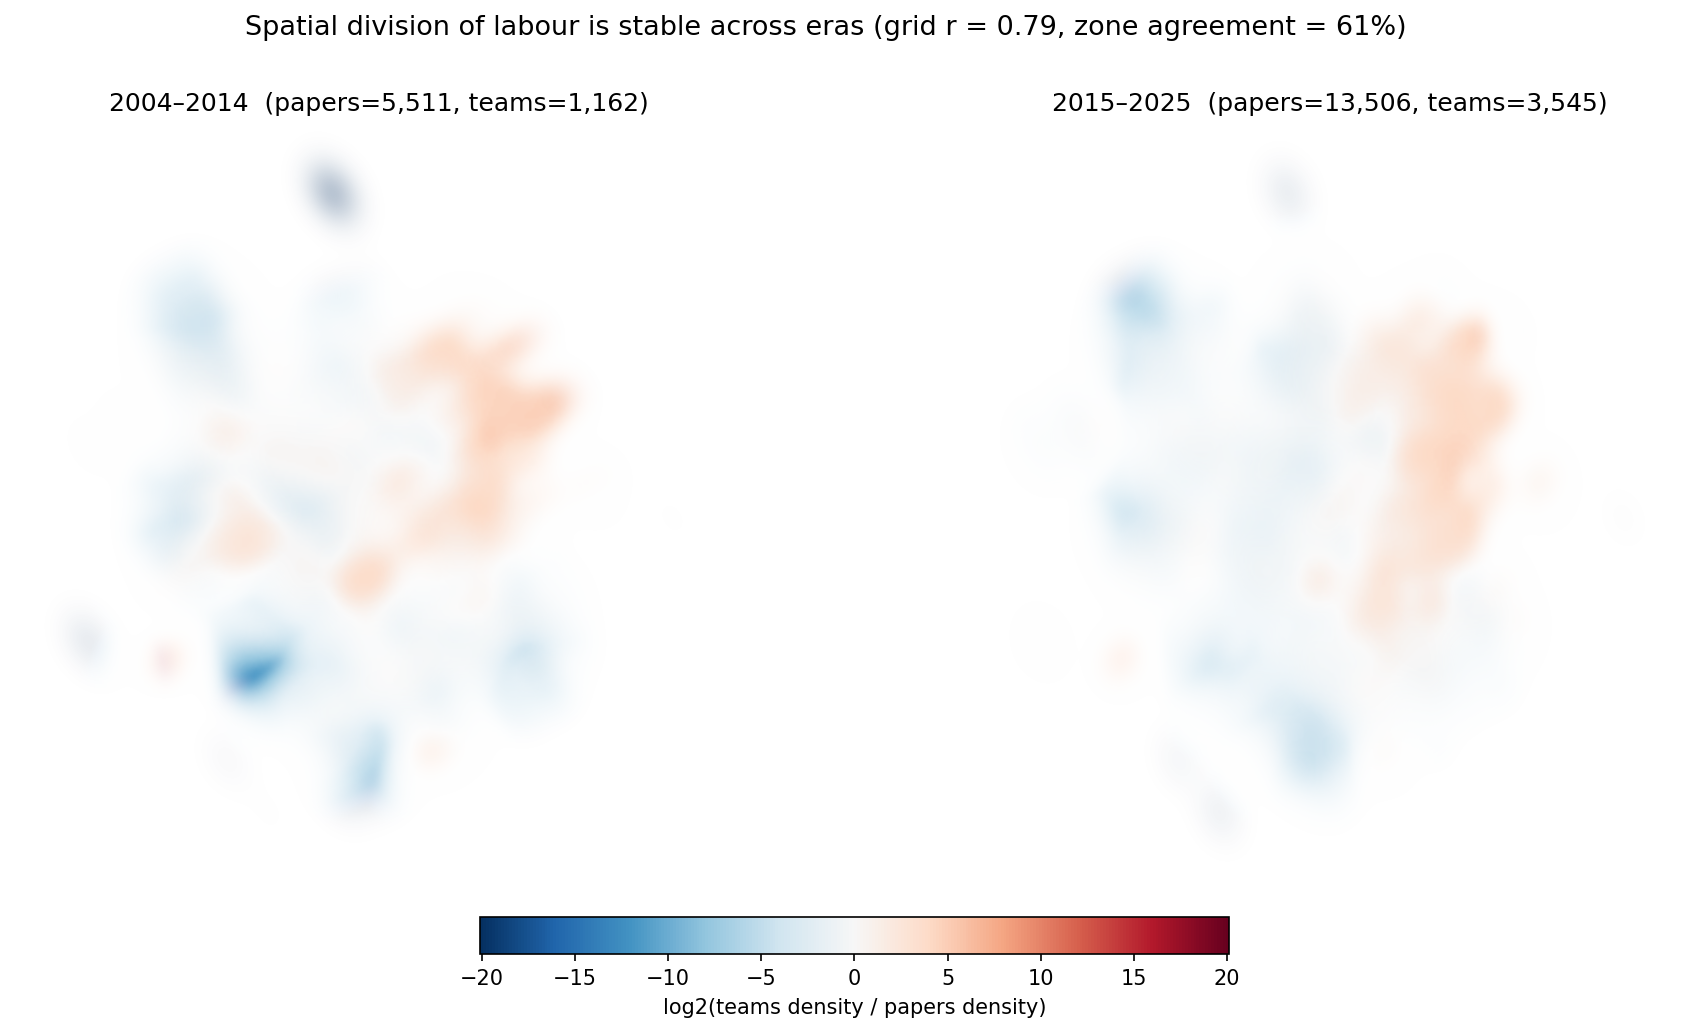

<Figure size 640x480 with 0 Axes>

In [2]:
%run density_eras.py

## 2 · Geographic specialization — Location Quotient

`LQ_c = (country c's share of iGEM teams) / (country c's share of SynBio papers)`
over the 2004–2025 co-existence window. `LQ > 1` = outsider-tilted, `LQ < 1` =
core/insider-tilted.

Saved → /Users/cristian/Desktop/GitHub/igem-synbio/assets/reports/geography_lq.png

Totals — iGEM team-countries: 4,707 | paper-countries 2004-25: 21,229 | all-years: 21,229

TOP outsider-tilted (LQ>1, teams>=10):
country                teams  iGEM%   lit%     LQ   log2
Hong Kong                105   2.2%   0.3%   6.96   2.80
Greece                    52   1.1%   0.2%   6.34   2.66
Kazakhstan                14   0.3%   0.0%   6.31   2.66
Macao                     15   0.3%   0.1%   5.20   2.38
Taiwan                   135   2.9%   0.6%   4.61   2.21
Mexico                    82   1.7%   0.4%   4.51   2.17
Lithuania                 12   0.3%   0.1%   2.85   1.51
Turkey                    43   0.9%   0.4%   2.23   1.16
China                   1422  30.2%  13.8%   2.20   1.14
United Arab Emirates      11   0.2%   0.1%   1.77   0.82
Indonesia                 23   0.5%   0.3%   1.73   0.79
Chile                     12   0.3%   0.2%   1.69   0.76
Canada                   235   5.0%   3.0%   

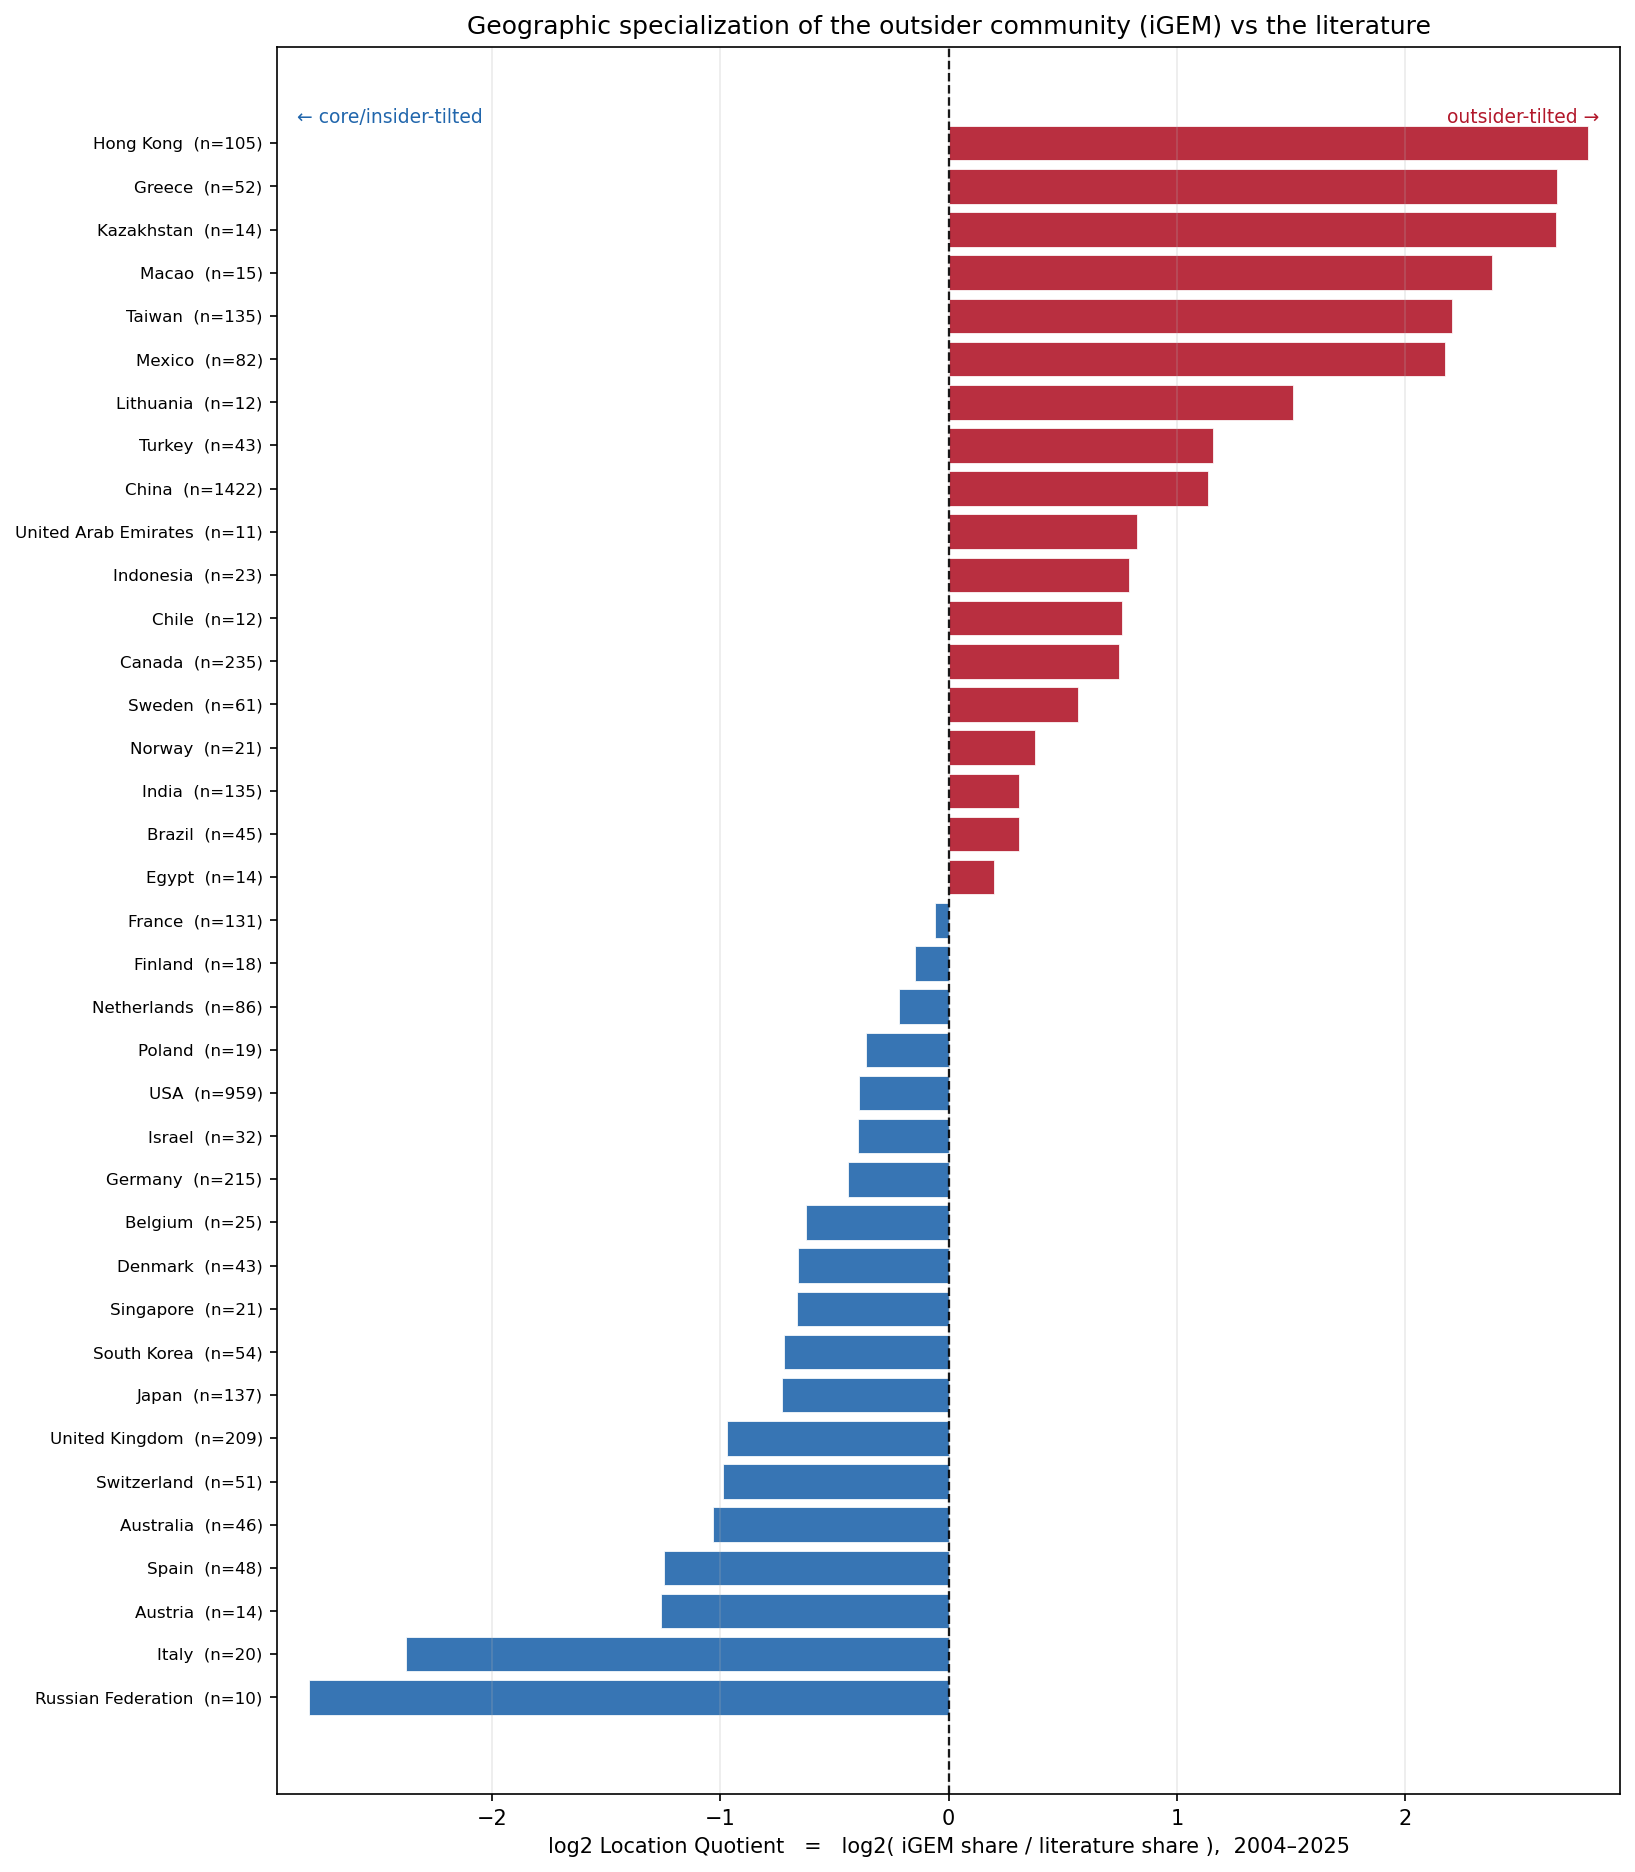

<Figure size 640x480 with 0 Axes>

In [3]:
%run geography_lq.py

## 3 · Country × overlap-topic matrix

Breaks each overlap topic's nearby teams down by country and tests whether
outsider-tilted (high-LQ) countries concentrate in the iGEM-led topics.

> Depends on the `geography_location_quotient.tsv` written by §2 above.

HYPOTHESIS: do outsider-tilted countries concentrate in iGEM-led topics?
  corr(country log2-LQ, precedence orientation): Pearson r=0.233 (p=0.172), Spearman rho=0.416 (p=0.012)
  (negative r => higher-LQ/outsider countries sit in more iGEM-led topics)

  Outsider-tilted countries (LQ>1, n=17): mean orientation delta_q1 = +0.03, mean frac in iGEM-led topics = 0.51
  Core-tilted countries    (LQ<1, n=19): mean orientation delta_q1 = -1.11, mean frac in iGEM-led topics = 0.64

Per-country (ordered as the matrix rows, top = most outsider-tilted):
  country               LQ  orient %iGEMlead  nearby
  Hong Kong           6.96   -0.03       50%      38
  Greece              6.34   +1.38       44%      23
  Macao               5.20   -0.03       50%      10
  Taiwan              4.61   -0.85       68%      34
  Mexico              4.51   -1.29       64%      25
  Lithuania           2.85   -1.38       75%       4
  Turkey              2.23   -1.21       56%      18
  China               2.20

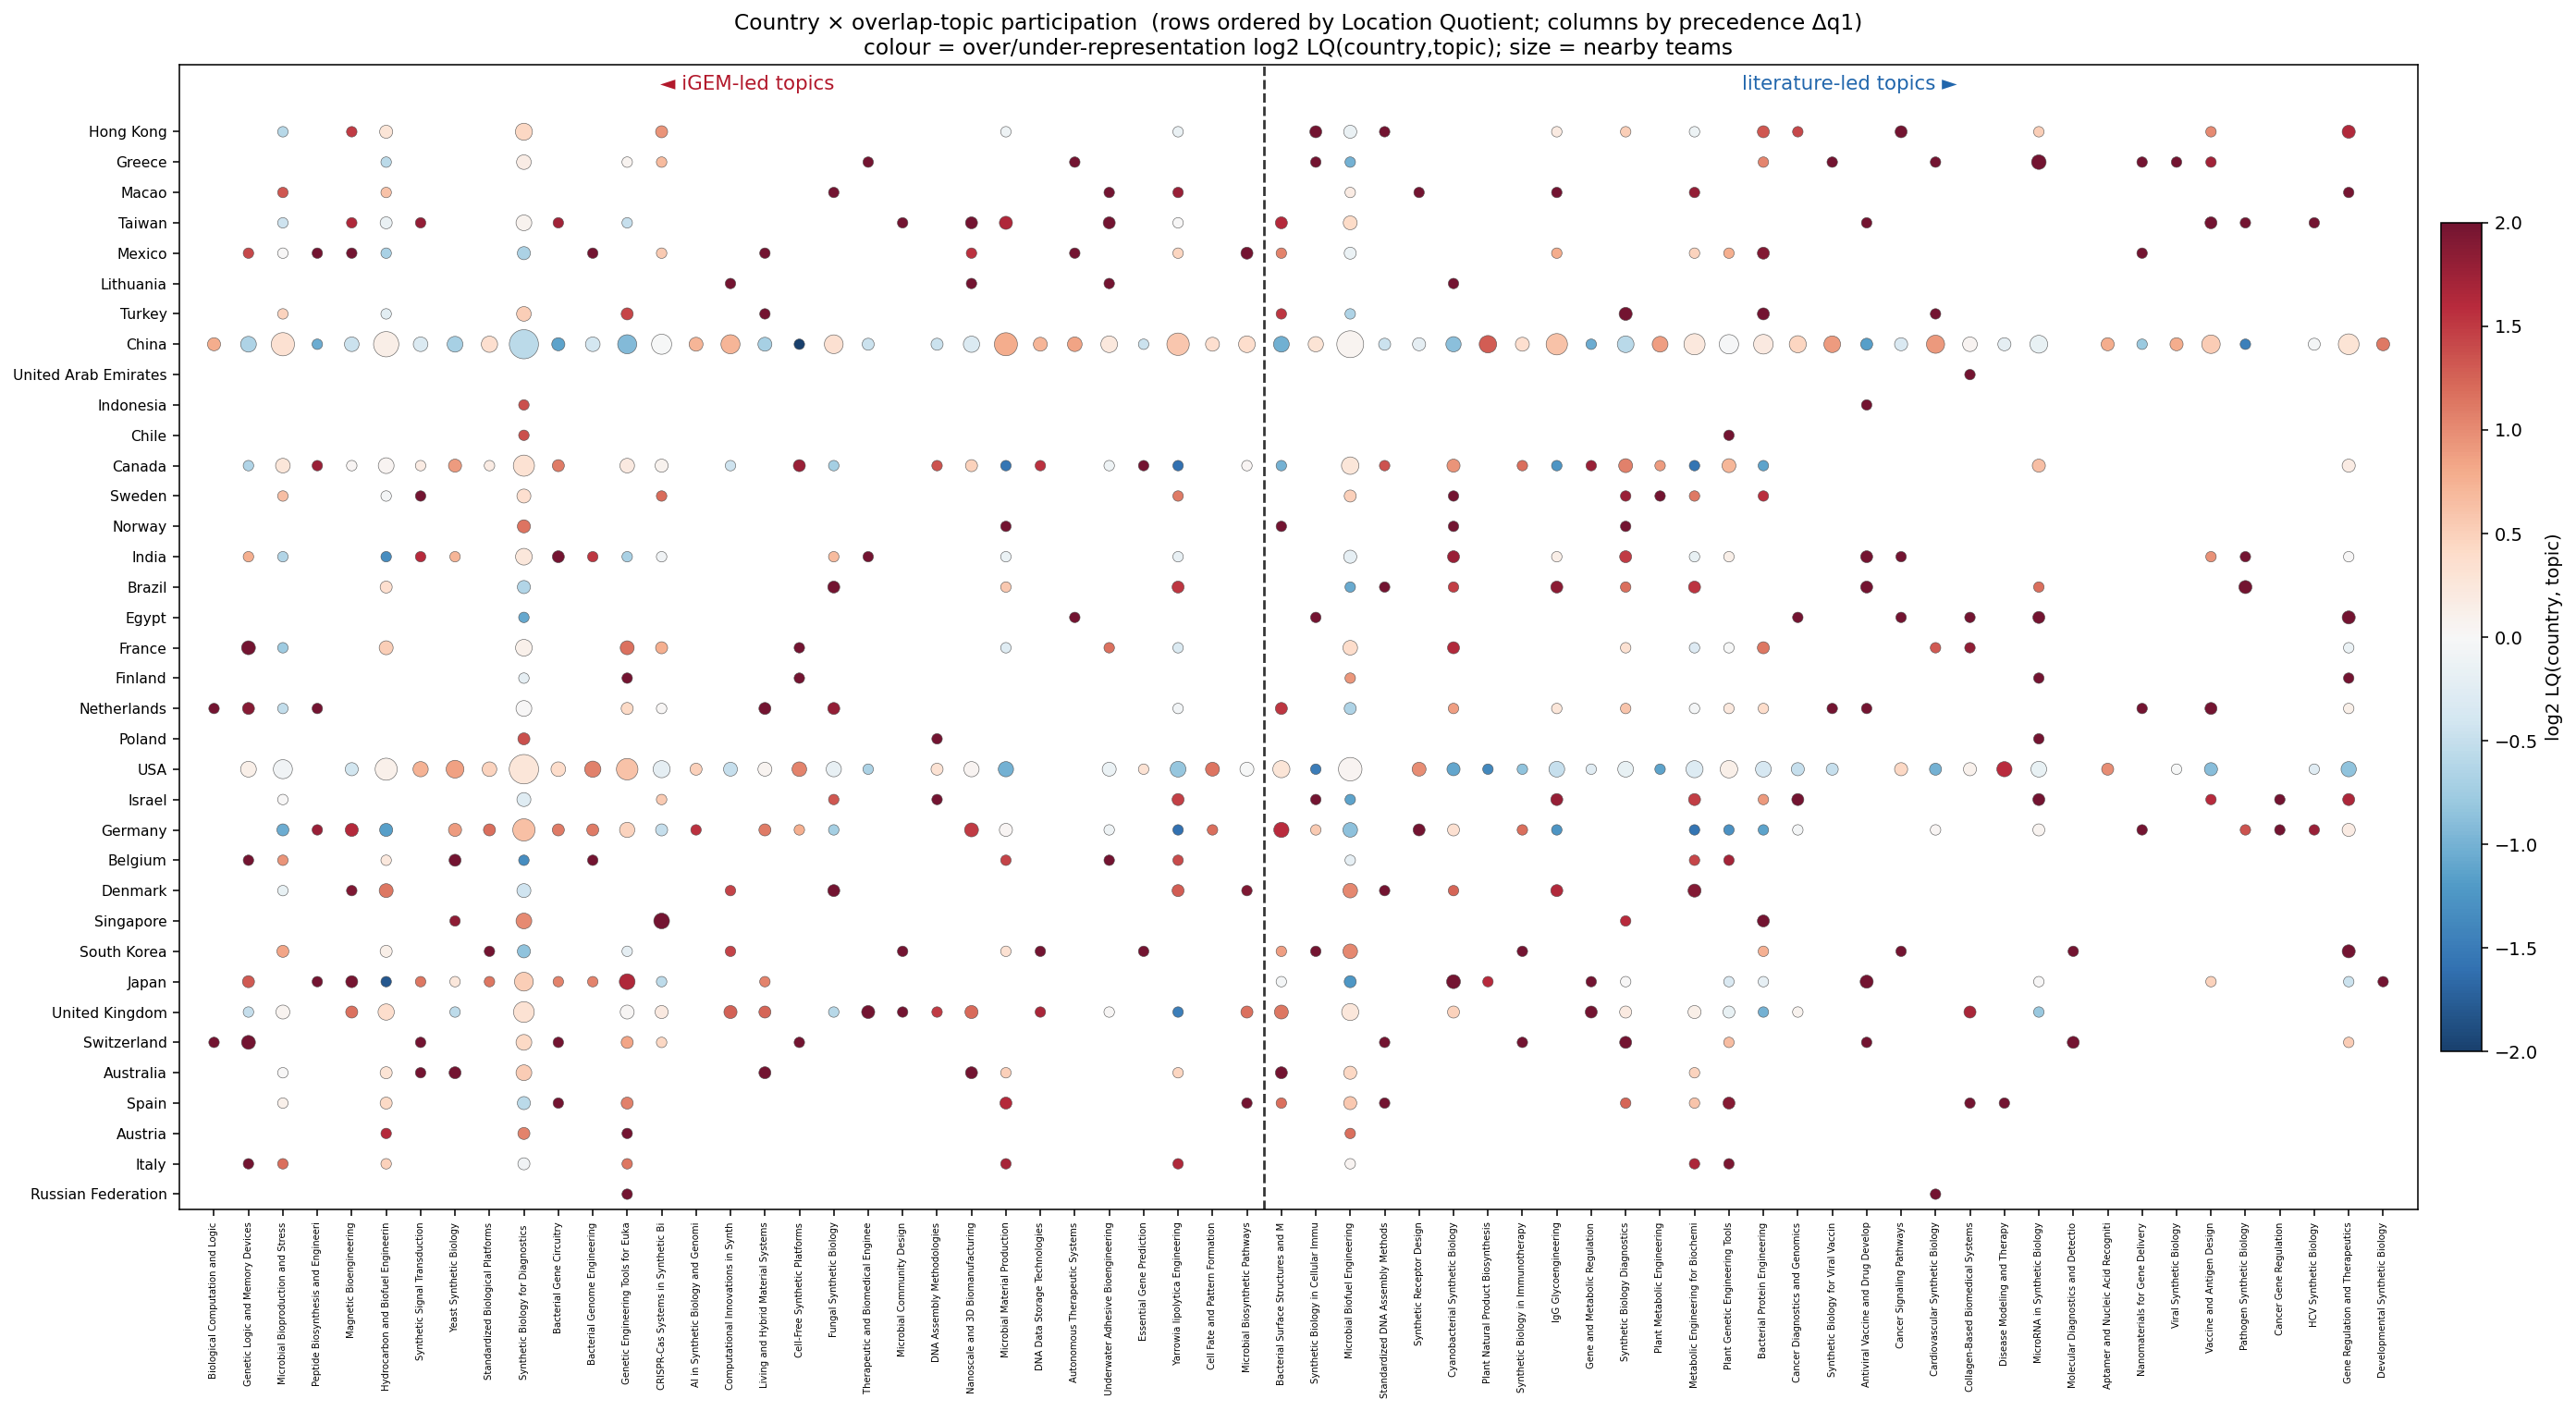

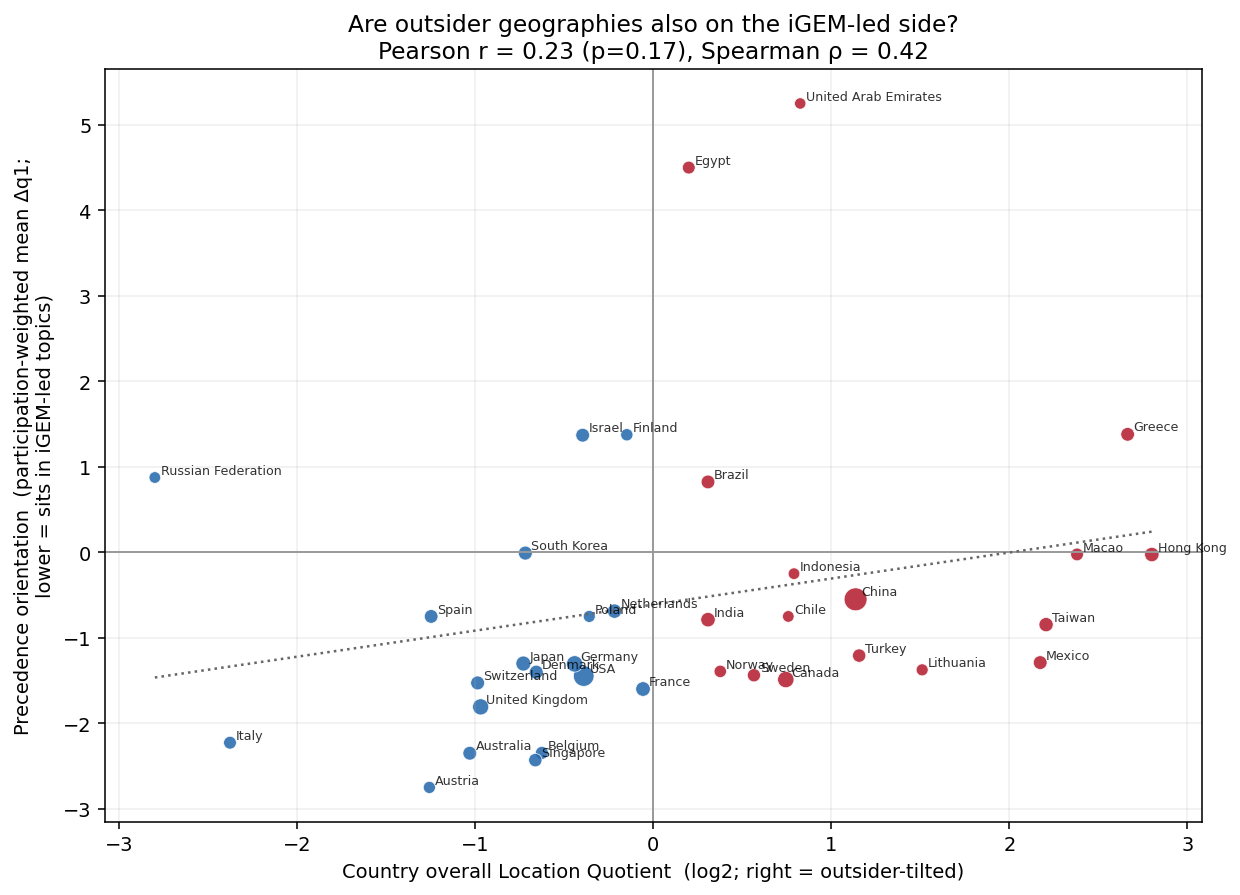

<Figure size 640x480 with 0 Axes>

In [4]:
%run geography_topic_matrix.py

## 4 · Precedence robustness (R1)

Reproduces the shipped `overlap_precedence_full.tsv` as a correctness check, then
verifies (a) sign stability of the lead/lag direction across Q1 / median / mean
and (b) split stability across radius-multiplier × minimum-support parameters.

Reproduced 64 overlap topics (shipped: 64); max |delta_q1 diff| vs shipped = 0.000

(a) Sign stability across Q1 / median / mean:
    49/56 non-zero topics agree in sign across all three (88%).
    by delta_q1    : 31 iGEM-first, 31 papers-first
    by delta_median: 37 iGEM-first, 20 papers-first
    by delta_mean  : 37 iGEM-first, 27 papers-first

(b) Split stability across neighbourhood parameters (direction by delta_q1):
     radius min_n tested iGEM1st pap1st flips*
        1.0     3     52      24     24      5
        1.0     5     43      21     18      5
        1.0    10     28      13     12      3
        1.5     3     64      31     31      0
        1.5     5     59      29     28      0
        1.5    10     43      21     20      0
        2.0     3     66      36     27      4
        2.0     5     62      33     26      4
        2.0    10     56      30     23      4
    * sign flips of delta_q1 vs the default (1.5, 3) run, among shared topics.

Saved → /Users/cristia

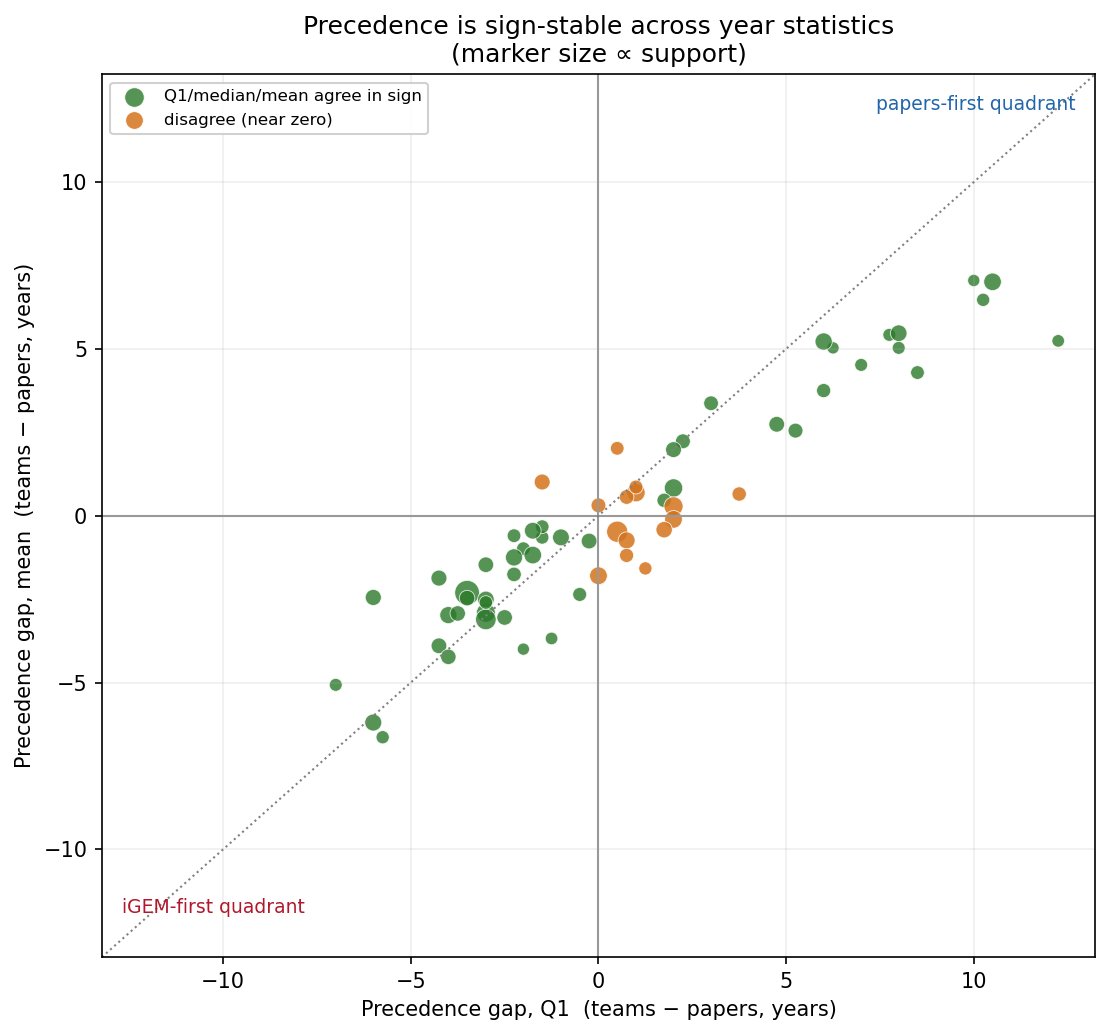

<Figure size 640x480 with 0 Axes>

In [5]:
%run precedence_robustness.py

## Generated figures

The PNGs produced above, embedded here so the appendix is self-contained.

── density_ratio_eras.png


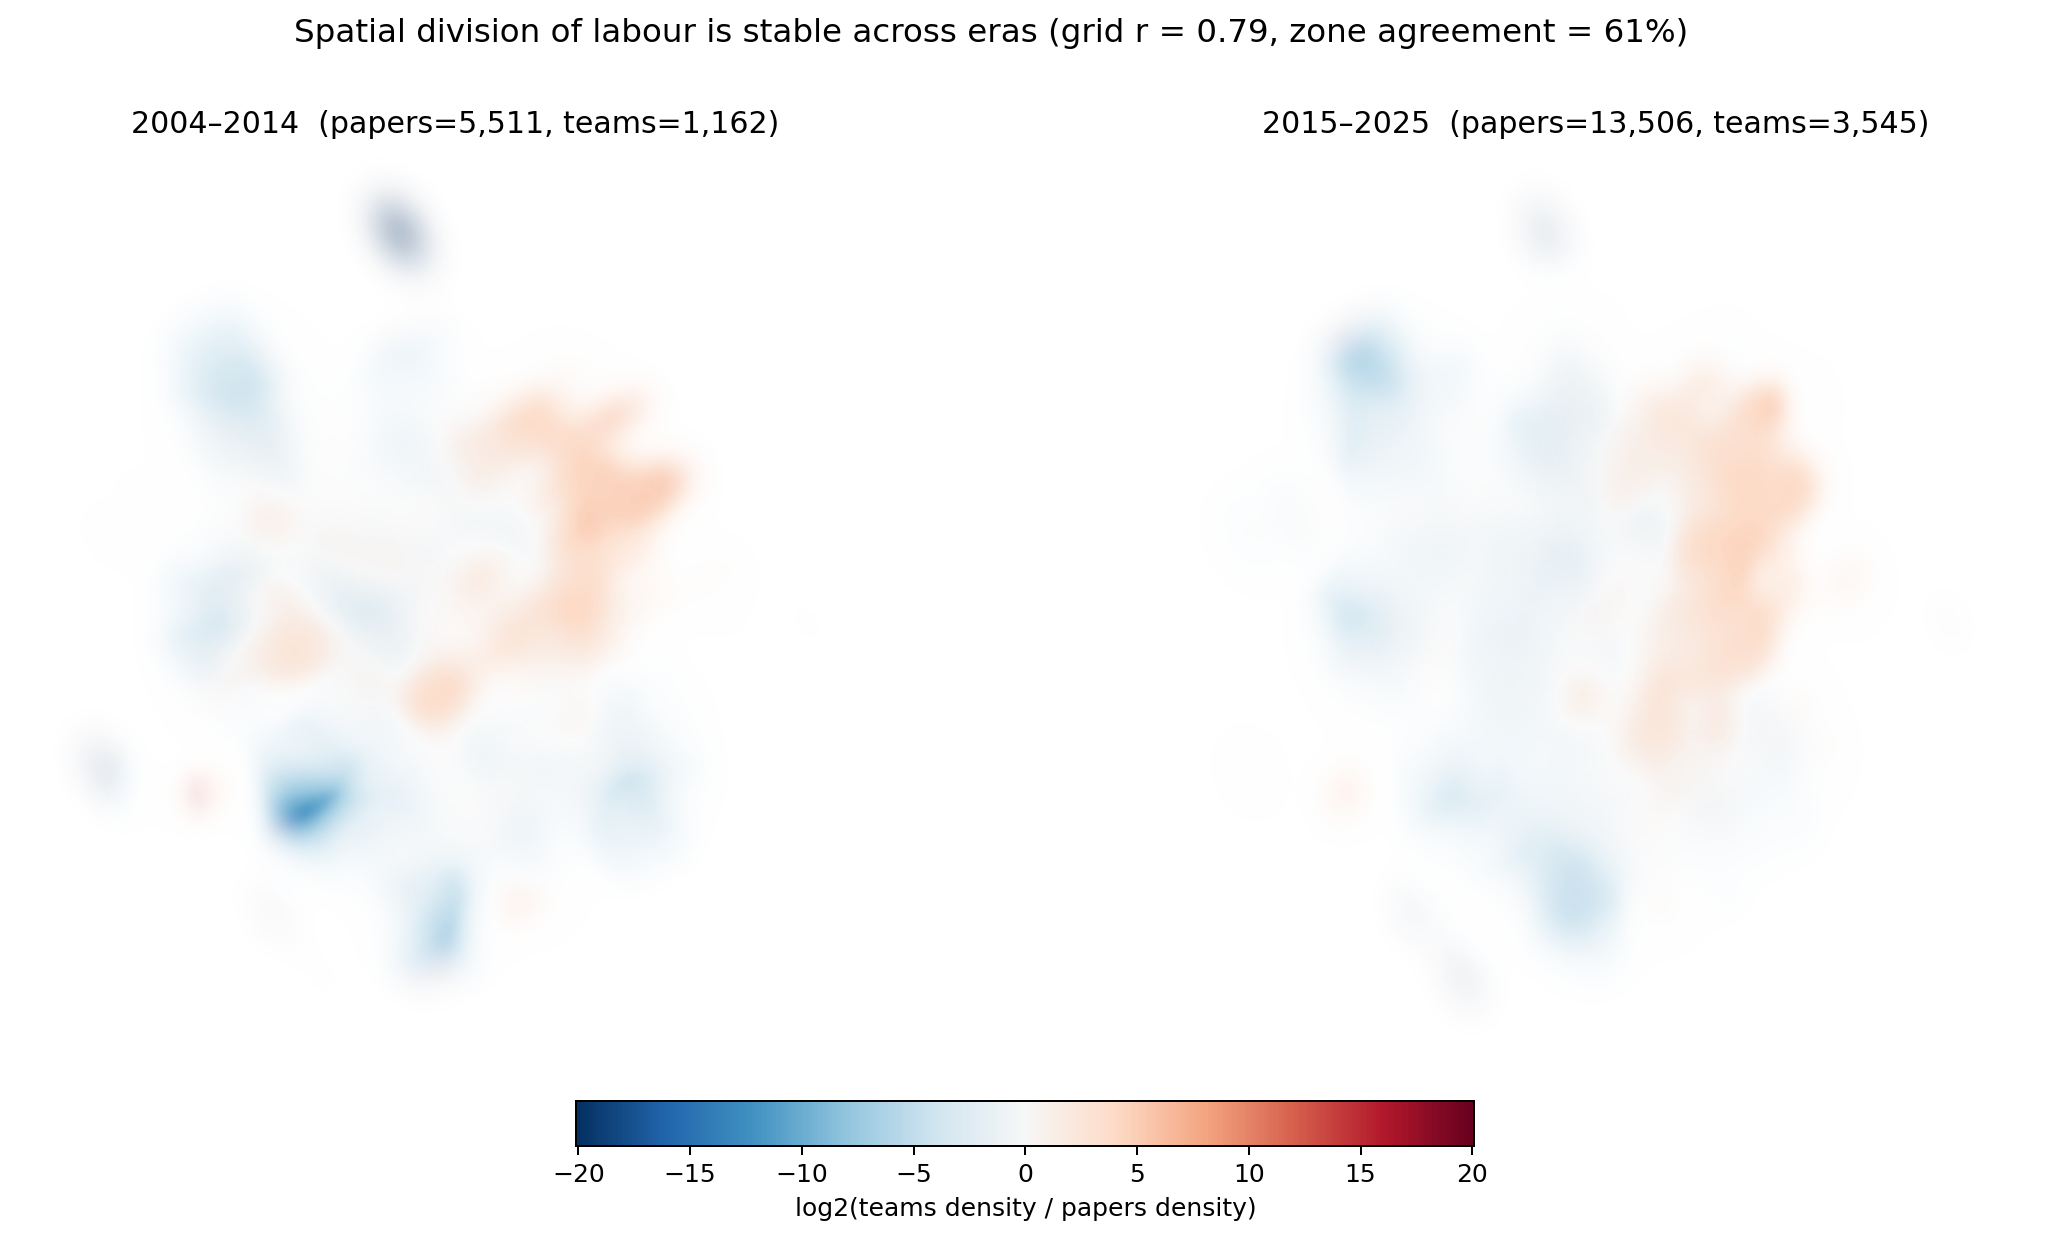

── geography_lq.png


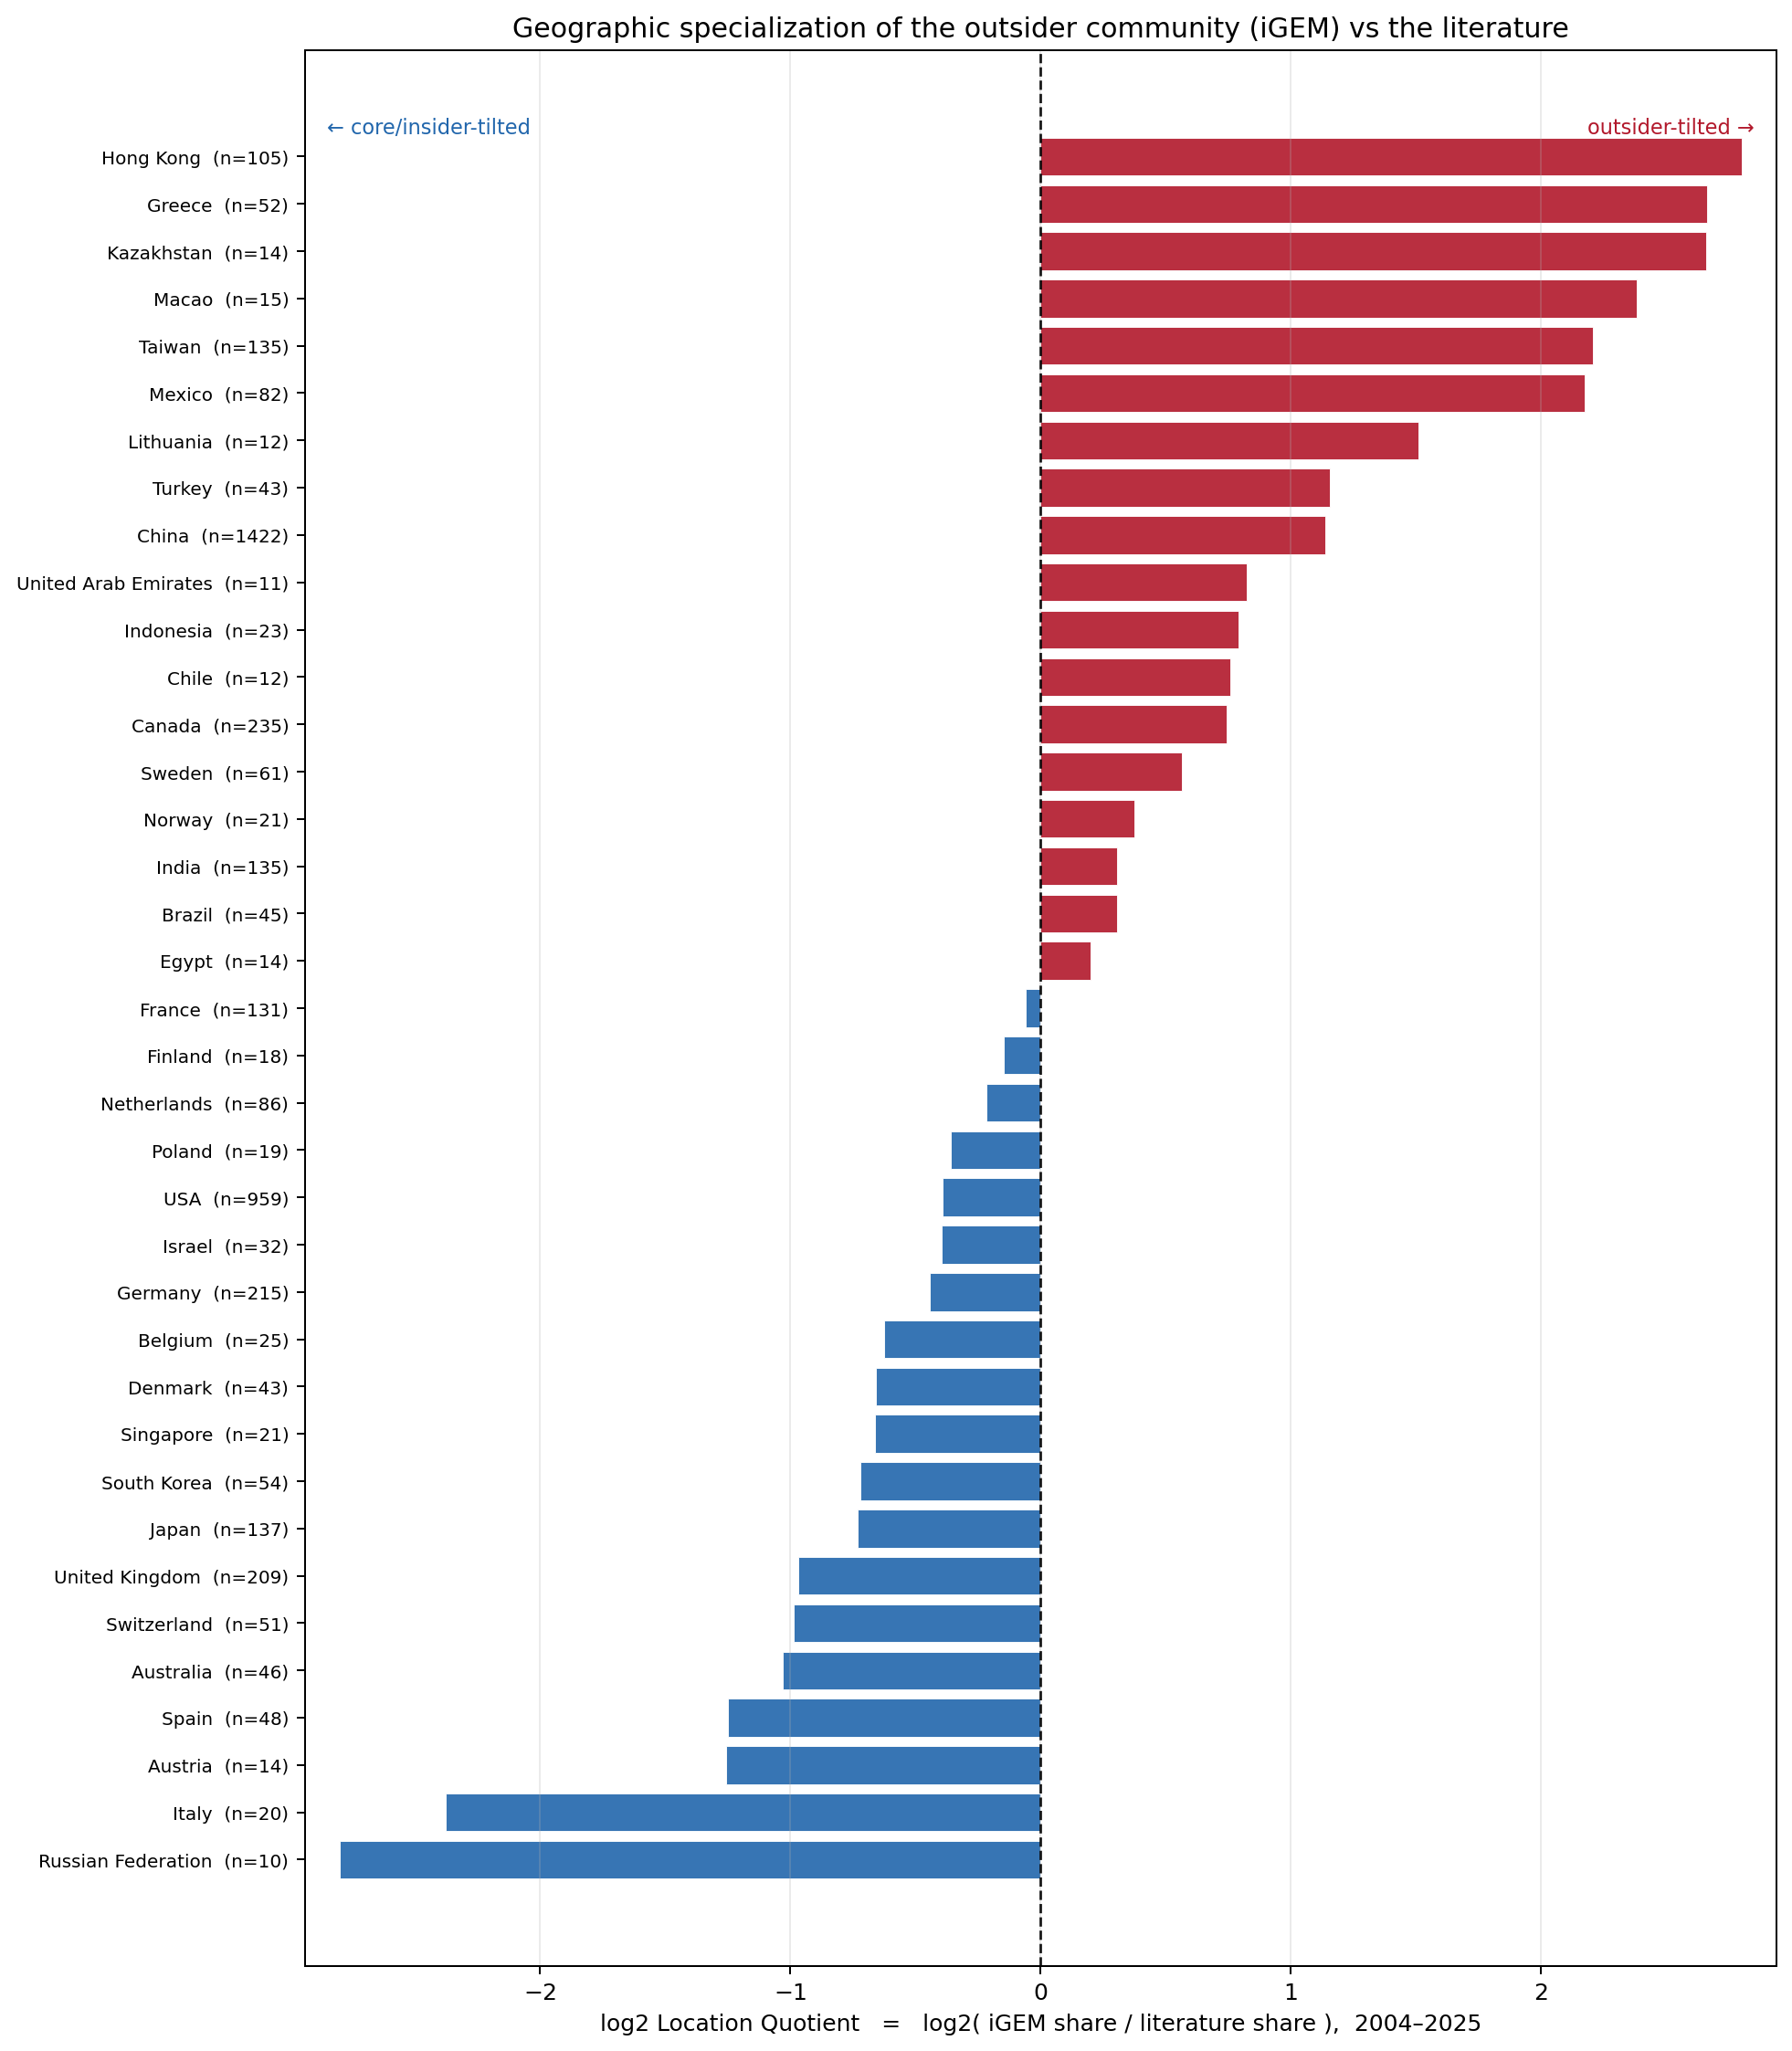

── geography_topic_matrix.png


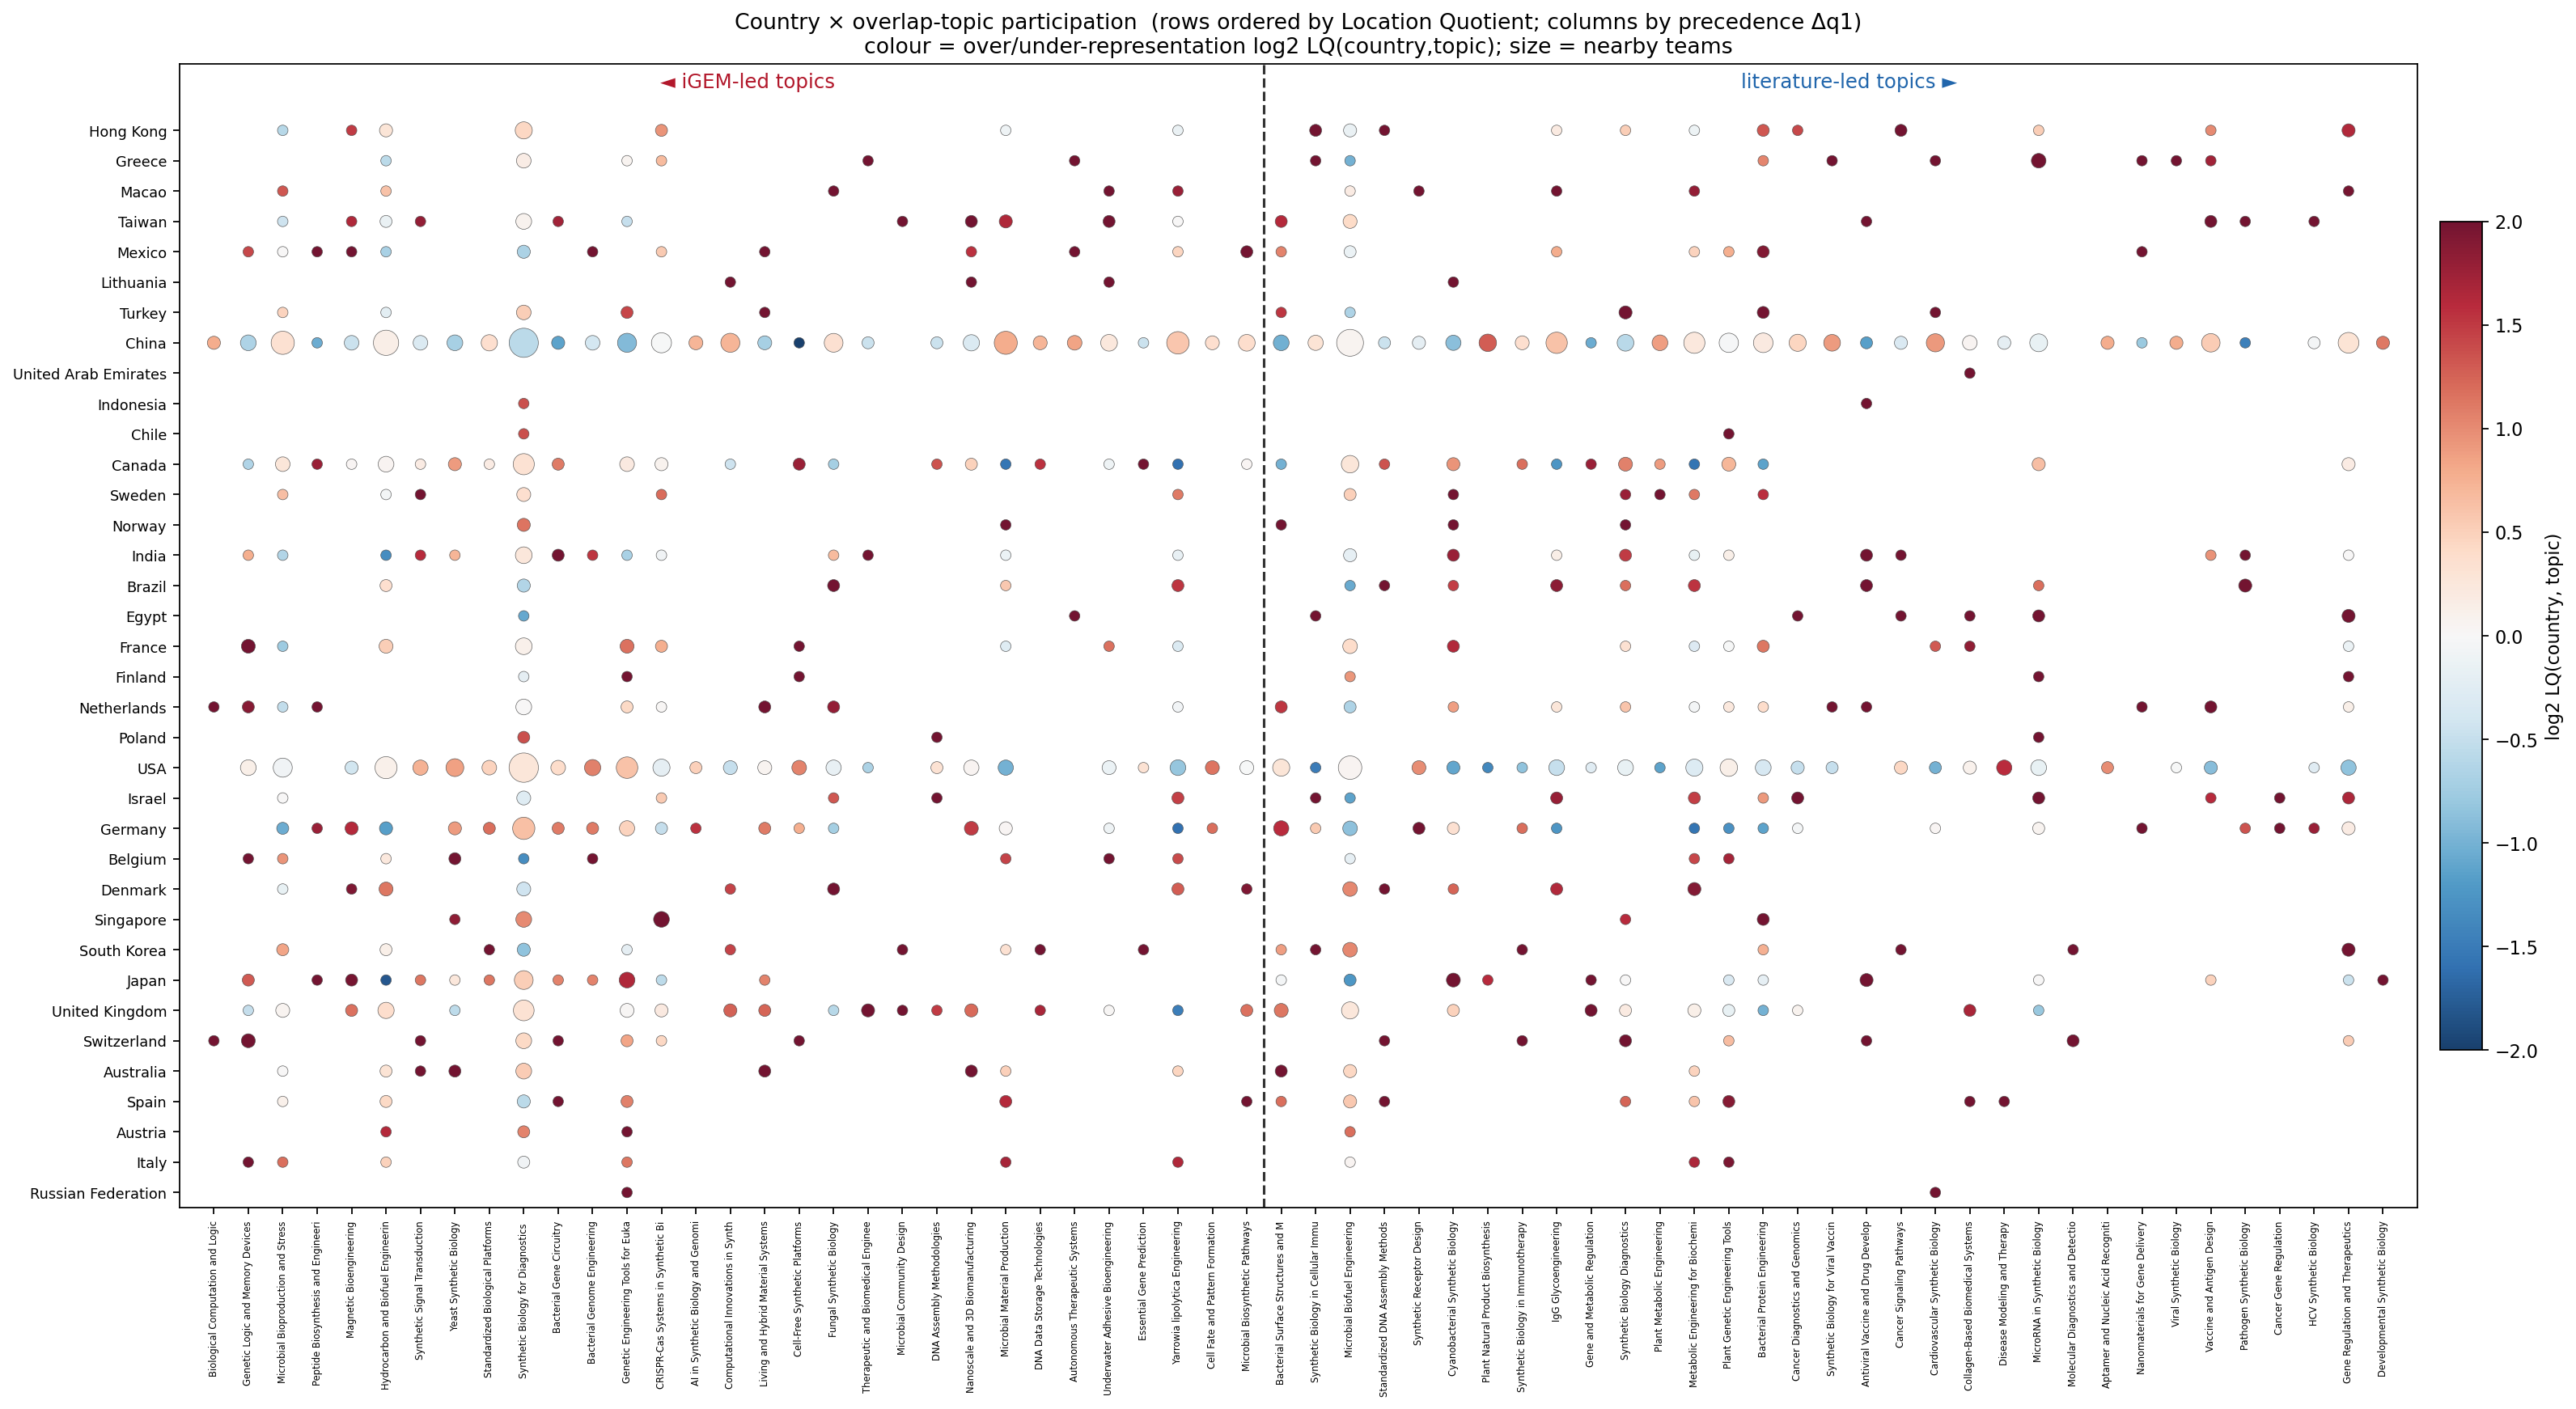

── geography_lead_orientation.png


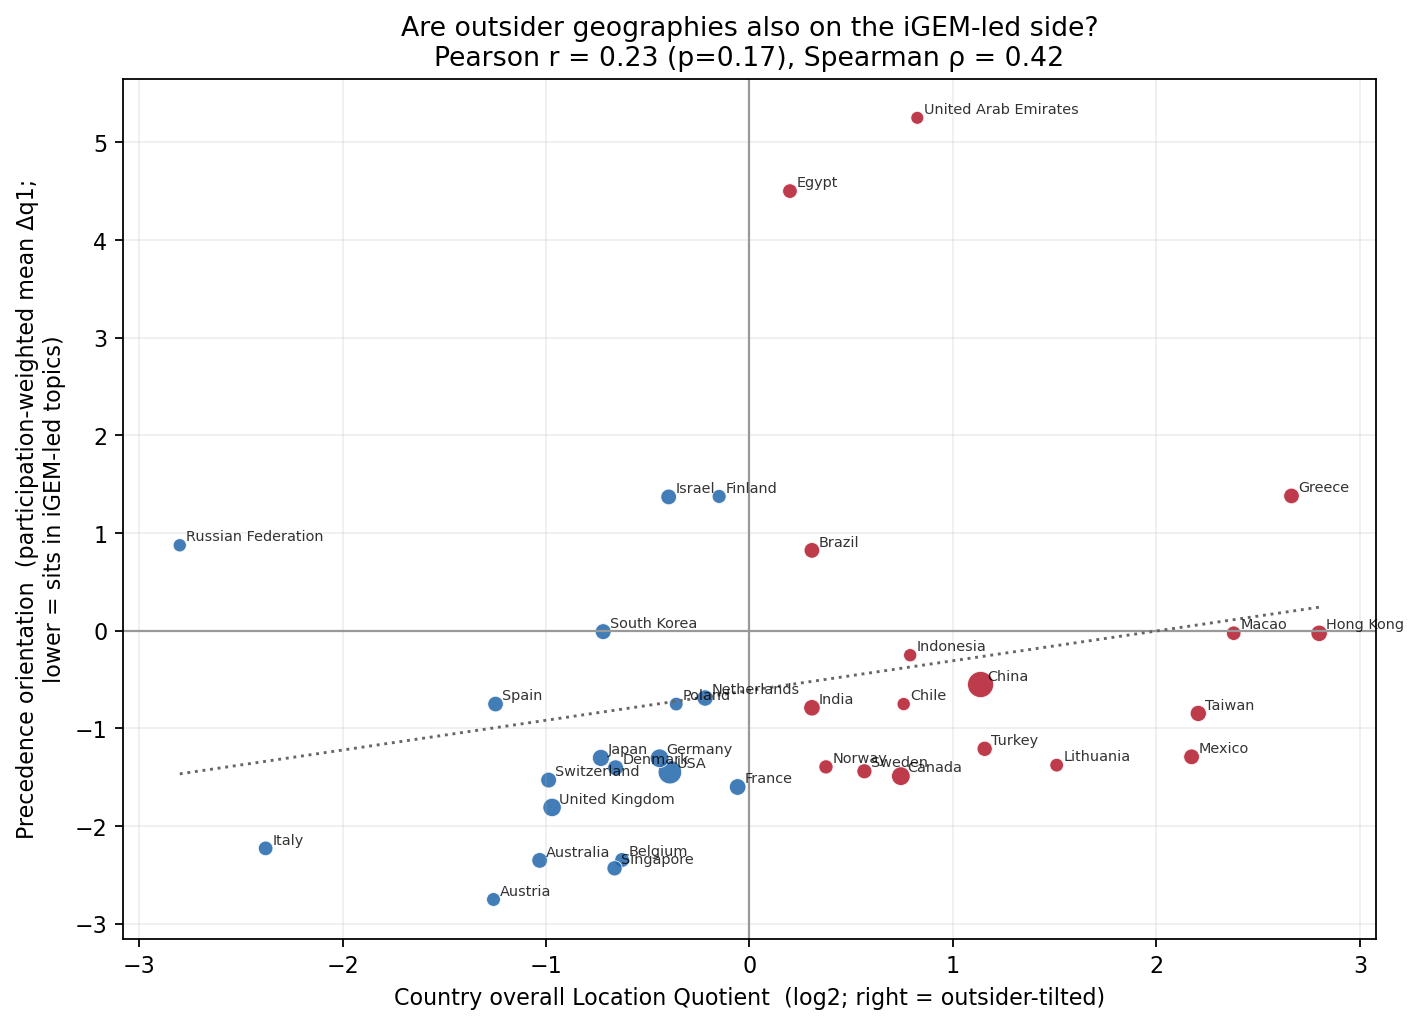

── precedence_robustness.png


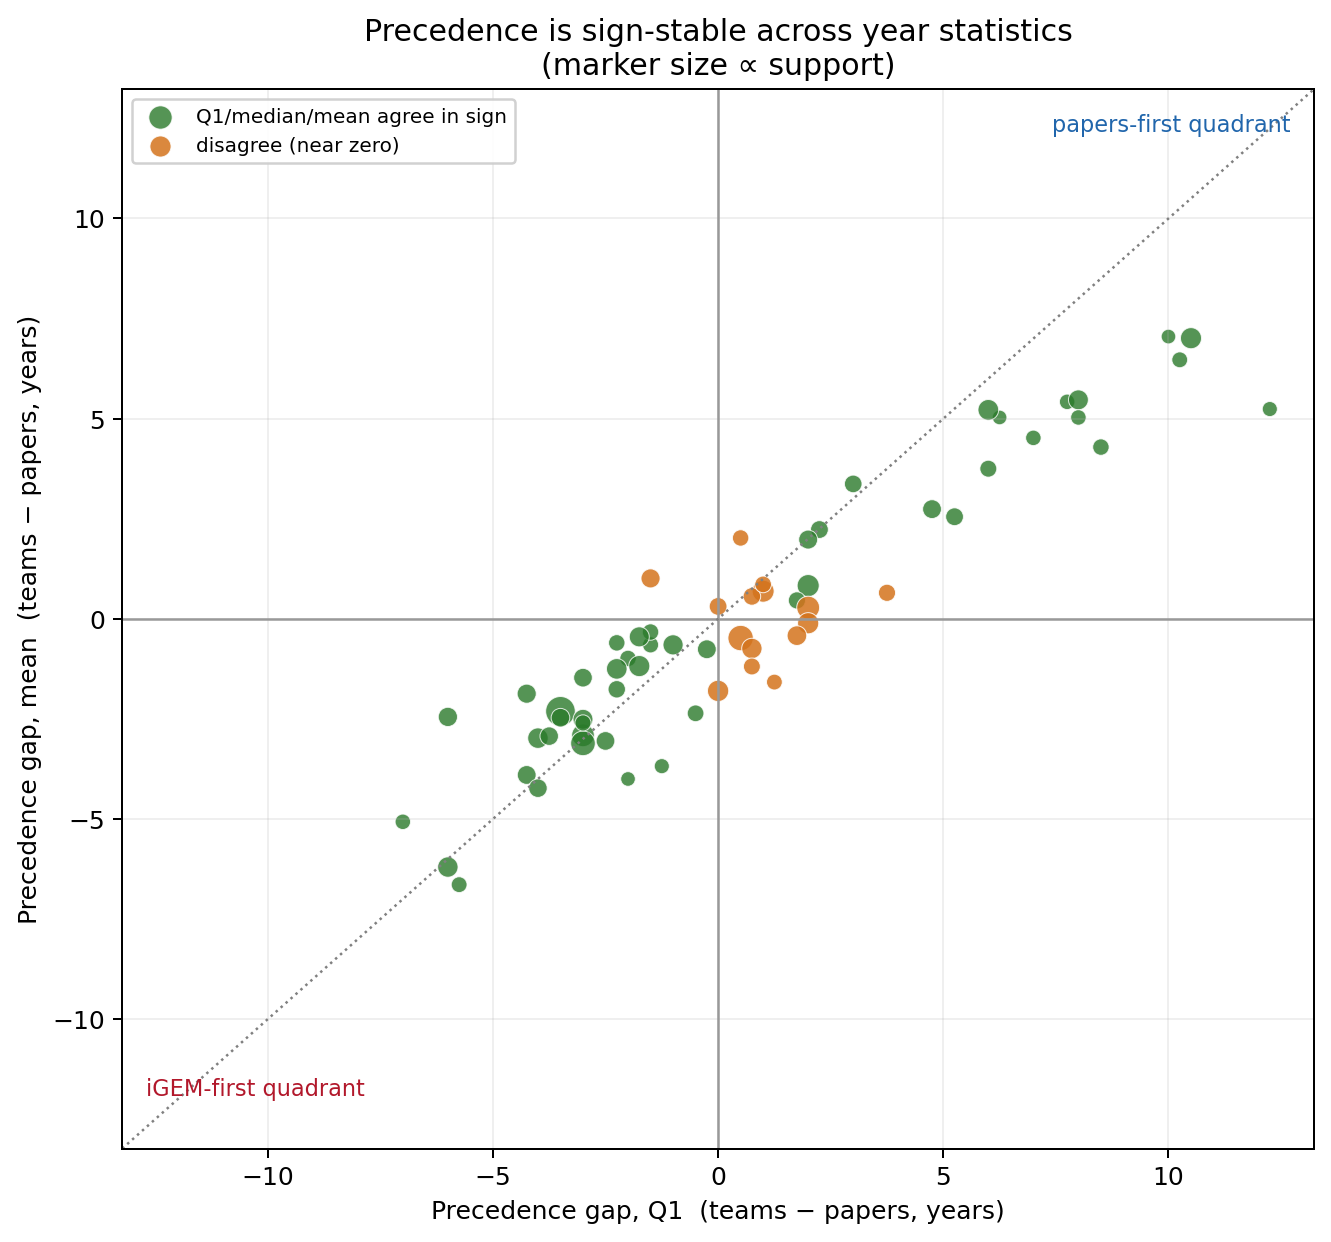

In [6]:
from IPython.display import Image, display

_figs = [
    "density_ratio_eras.png",
    "geography_lq.png",
    "geography_topic_matrix.png",
    "geography_lead_orientation.png",
    "precedence_robustness.png",
]
for _f in _figs:
    _p = REPORTS / _f
    print(f"── {_f}" + ("" if _p.exists() else "   (MISSING)"))
    if _p.exists():
        display(Image(filename=str(_p)))